<h1 style="color: steelblue; font-size: 50px; text-align: center; font-weight: bold;">Simple Linear Regression Implementation</h1>


In this notebook I implement the 9 wheels of machine learning, using an example from simple linear regression. The idea is to get a deeper understanding of what is going on in each wheel. I also make use of some synthetic data. A brief description of each of the 9 wheels of Machine Learning, as studied in the `Statistical Machine Learning` course and taught by the renowned [Dr. Ernest Fokué](https://www.rit.edu/directory/epfeqa-ernest-fokoue) from Rochester Institute of Technology, is given below:

1. <strong>Problem Formulation</strong>: In our world today Machine Learning (ML) is used both as a tool and an active field of research. In industry, ML is seldom used without a business objective in mind. In particular most companies turn to ML tools to answer some pain point in their day-to-day operations. A classic example includes retail companies using Clustering methods (some form of ML) to gain insights into the behaviours of customers, in order to maximize revenue by tailoring their services to fit the specific customer's needs.<br> At this stage, after understanding the business problem, machine learning engineers, together with stakeholers, tend to define business objectives that guide the flow of the project. In more technical terms, they define what is known as a loss function, which gives information on how well the solution that will be built is performing.<br><br>
2. <strong>Data Understanding</strong>: After formulating what exactly the business problem is, the next stage is to look for data related to the business problem. The ML engineer, together with stakeholders, deliberate on the different features that are necessary for the problem. This defines the input space of the dataset. Now depending on whether the task is a supervised, unsupervised, or semi-supervised, each of these observations in the input space may have to be labeled to carry out the learning task. <br> Also at this stage, the ML engineer carries out some `Exploratory Data Analysis` (EDA) to better understand the data that has been collected which will inform their choices throughout the learning process. One thing I learned from class is that while some insights may be got from EDA, it is better to allow a systematic procedure to confirm that insight rather than just take it as is and perform your modeling on it. For instance if in your regression analysis you notice that some predictors do not have a high predictive power for the response variable, rather than drop them out at the EDA stage, it is better to allow a process like the [`Akaike Information Criterion`](https://en.wikipedia.org/wiki/Akaike_information_criterion) drop them, rather than drop them by yourself at this stage.<br><br>
3. <strong>Hypothesis Space</strong>: The hypothesis space is defined by the machine learning engineer and represents the set of all candidate functions that could potentially explain the relationship between the inputs and the outputs. The choice of hypothesis space is informed by insights gained from the `Wheel 2` where we performed the EDA. For instance if in your EDA the scatter plots and correlation analysis revealed that most of the predictors have a strong linear trend with the response variable, then a hypothesis space for linear functions would be ideal for that task. The choice of hypothesis space introduces the possibility of bias (in the bias-variance tradeoff) since restricting the model to a particular family of functions limits the kinds of relationships it can represent. If the true underlying relationship lies outside this chosen family, the model may systematically underfit the data, regardless of how well its parameters are optimized.<br> For this implementation the focus is on simple linear regression, meaning that the chosen hypothesis space is linear functions of the form $$h_{\theta}(x) = \theta_0 + \theta_1x.$$ where $\theta_0$ and $\theta_1$ are parameters to be learned from the data. A heuristic for choosing a hypothesis space is to choose more than one hypothesis space for your specific task. You could for instance choose a space of linear functions, a space of decision trees, and a space of k-Nearest Neighbor models. The intuition behind this is to be able to choose the better performing model. <br><br>
4. <strong>Principle of Learning</strong>: At this stage, we want to define a metric that allows us to quantify how well our model has learned from the data. In other words, we need a principle or criterion that tells us whether the model is doing a good job at capturing the underlying relationship between inputs and outputs. <br> For supervised learning tasks, this principle is usually defined in terms of a `loss function`. The loss function measures how far off the model's predictions are from the true labels given in the data. By minimizing this loss, the model "learns" the optimal parameters that best fit the data within the chosen hypothesis space. The principle of learning ensures that we have a quantitative way to evaluate the model, rather than relying on intuition or visual inspection alone. This formalizes the learning process and makes it possible to compare different models or hypothesis spaces rigorously. For this implementation, we make use of the `Mean Square Error` as the loss function, which is one of the commonest loss functions for regression tasks. It is defined by $$MSE(\theta) = \frac{1}{n}\sum\limits_{i=1}^{n}\left(y^{(i)}-h_{\theta}(x^{(i)})\right)^2$$ where $n$ is the sample size of the data.<br><br>
5. <strong>Algorithmic Implementation</strong>: Up until this point, apart from EDA in wheel 2, almost no coding has been done. In this step we translate the formal principles and hypothesis space into a concrete computational procedure. This involves selecting an algorithm that can efficiently optimize the parameters of the chosen hypothesis space according to the learning principle defined. Different algorithms exist such as the [`Gradient Descent`](https://en.wikipedia.org/wiki/Gradient_descent) (which is an algorithm for convergence to the minimum point which makes use of the fact that since the gradient of the function at a point in the domain of the function points in the direction of steepest ascent, then we go in the opposite direction of the gradient at that point) and, for the case of Linear Regression, the [`Normal Equation`](https://www.statlect.com/glossary/normal-equations) which is just the solution to the system of linear equations derived from the learning principle.<br> It is noteworthy to mention that the normal equations do no exist for all function spaces and even in the case of the Linear Regression, may become computationally expensive for high dimensional datasets. Additionally, for lower dimensional datasets with little to no multicollinearity, the solutions are unique, thus a well implemented gradient descent should have the solutions converging to the solutions of the closed form.<br><br>
6. <strong>Refinement and Regularization</strong> <br><br>
7. <strong>External Validation</strong> <br><br>
8. <strong>Statistical Inference</strong> <br><br>
9. <strong>Deployment</strong>




In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Callable

In [249]:
class SLR:
    # TODO: Implement train_test split and then use it throughout the class.
    ## Implement wheels 7 and 8
    ## and then a main method that ties all these guys together.
    
    def __init__(self, sample_size:int, f:Callable[[float], float] = lambda x: (2*x)+1, mean:float=0, variance:float=0.3):
        self.sample_size = sample_size
        self.X = np.random.uniform(0,1, self.sample_size)
        true_error = np.random.normal(mean, variance, self.sample_size)
        self.y = f(self.X)+true_error
        self.X_design = np.column_stack([np.ones(self.sample_size), self.X])


    ## Wheel 2
    def plot_data(self):
        plt.scatter(self.X, self.y)
        plt.xlabel("Features")
        plt.ylabel("Label")
        plt.title("Observed Data")
        plt.show()


    def plot_hist(self):
        plt.hist(self.X, bins=50)
        plt.xlabel('Feature')
        plt.ylabel('Count')
        plt.title('Histogram of feature')
        plt.show()


    def plot_boxplot(self):
        plt.boxplot(self.X)
        plt.xlabel("X")
        plt.ylabel("Values")
        plt.show()


    # def square_error_loss(self):
    
    # def empirical_risk(self, y_hat:np.array):
    #     return np.mean((self.y-y_hat)**2)


    ### Algorithmic Implementation:
    def train_test_split(self, ratio:list=[0.9, 0.1]):
        train_percent = ratio[0]
        test_percent = ratio[1]
        indices = np.random.permutation(self.sample_size)
        split_point = int(self.sample_size*train_percent)
        
        train_indices = indices[:split_point]
        test_indices = indices[split_point:]
        
        X_train = self.X_design[train_indices]
        y_train = self.y[train_indices]

        X_test = self.X_design[test_indices]
        y_test = self.y[test_indices]

        return X_train, y_train, X_test, y_test
    
    
    def closed_form(self):
        param = np.linalg.solve((self.X_design.T@self.X_design), (self.X_design.T@self.y))
        return param


    def gradient_descent(self, lr:float, max_iter:int=1000, epsilon:float=0.0001):
        param = np.zeros(self.X.ndim+1)
        
        for _ in range(max_iter):
            updated_param = param + (lr*(2/self.sample_size))*(self.X_design.T@(self.y-(self.X_design@param)))
            if np.linalg.norm(updated_param-param) < epsilon:
                break
            param = updated_param

        return updated_param


    def plot_model(self):
        param = self.closed_form()
        line = self.X_design@param

        plt.scatter(self.X, self.y)
        plt.plot(self.X, line, label="Regression Line", color="orange")
        plt.legend()
        plt.show()

    ### Wheel 6 ---- Cross validation for Ridge regularization
    def ridge_cv(self, values:list, k:int):
        indices = np.random.permutation(self.sample_size)
        X_shuffled = self.X_design[indices]
        y_shuffled = self.y[indices]
        
        data_folds = np.array_split(X_shuffled, k)
        label_folds = np.array_split(y_shuffled, k)

        train_size = self.X_design.shape[1]
        
        P = np.eye(train_size)
        P[0,0] = 0
        errors = {}

        for value in values:
            value_errors = []
            for idx, fold in enumerate(data_folds):
                cv_train_data = np.concatenate([arr for j, arr in enumerate(data_folds) if j!=idx])
                cv_train_labels = np.concatenate([arr for j, arr in enumerate(label_folds) if j!=idx])
                cv_test_data = fold
                cv_test_labels = label_folds[idx]
                n_train = cv_train_data.shape[0]
                # training on k-1 folds
                
                param = (np.linalg.solve(((cv_train_data.T@cv_train_data) + (n_train*value*P)), cv_train_data.T@cv_train_labels))

                # testing on the ith fold:
                fold_error = np.mean((cv_test_labels - cv_test_data@param)**2)
                value_errors.append(fold_error)

            errors[value] = np.mean(value_errors)
                
        return errors    

In [245]:
np.array([[1,2,3], [4,5,6]])

array([[1, 2, 3],
       [4, 5, 6]])

In [246]:
test_slr = SLR(sample_size=50)

In [247]:
test_slr.ridge_cv([1,2,3], 5)

{1: np.float64(0.11062308723137512),
 2: np.float64(0.1530695847545788),
 3: np.float64(0.19166124526507206)}

In [164]:
test_slr.y

array([1.30235285, 3.19493068, 1.82410516, 1.74401283, 2.43322553,
       1.81488599, 2.27978832, 1.20858175, 1.20972304, 2.71068592,
       0.85123816, 3.25972789, 2.4600523 , 1.51479074, 1.41161393,
       2.6409671 , 1.22056786, 1.70445428, 2.5356518 , 1.8721137 ,
       2.52198954, 1.20958781, 1.78730904, 2.76168371, 3.40215972,
       1.72974014, 1.79343362, 0.71066973, 1.57117734, 2.30118289,
       2.66459301, 1.58914965, 1.92711228, 1.74272901, 1.42527502,
       1.80358964, 2.42443475, 2.87856155, 0.89196723, 1.09105758,
       1.39959854, 2.87180947, 3.26467312, 2.51386937, 1.59558269,
       2.04477869, 2.52638547, 1.57266308, 1.04927894, 1.8478452 ])

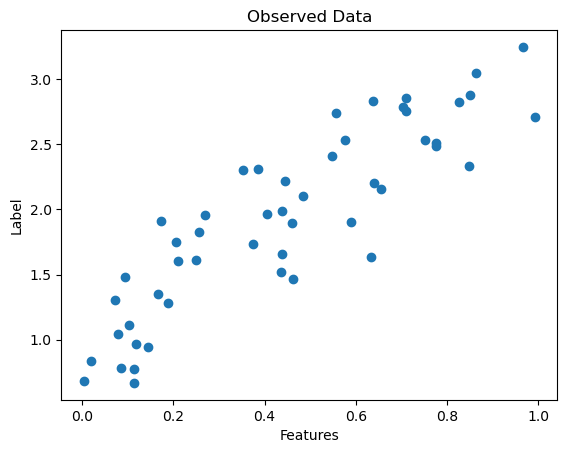

In [138]:
test_slr.plot_data()

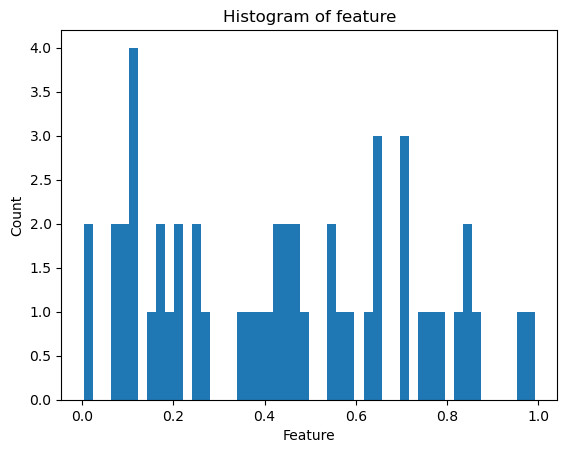

In [139]:
test_slr.plot_hist()

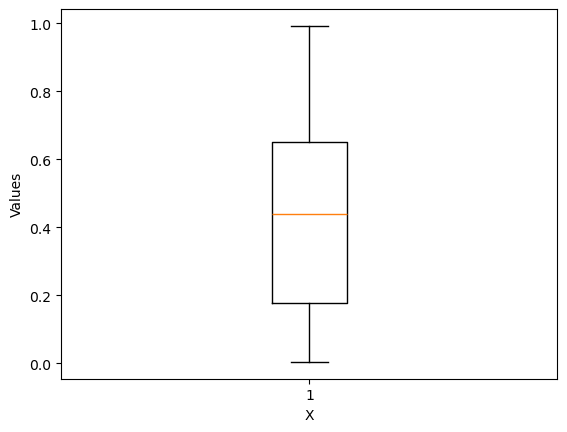

In [140]:
test_slr.plot_boxplot()

In [141]:
test_slr.closed_form()

array([0.96151586, 2.20226265])

In [142]:
test_slr.gradient_descent(0.3)

array([0.96151586, 2.20226265])

In [143]:
test_slr.X.ndim

1

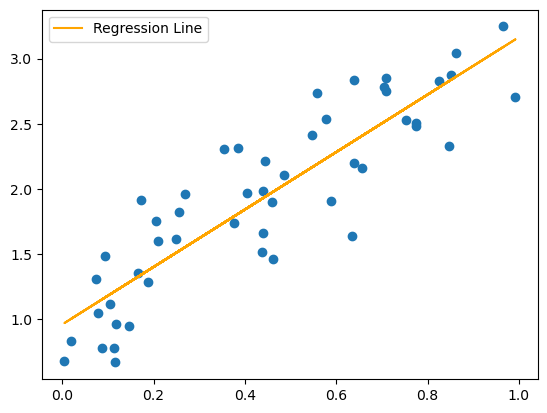

In [144]:
test_slr.plot_model()

In [252]:
!ls

anaconda3				  Public
Anaconda3-2024.10-1-Linux-x86_64.sh	  R
bin					  README.md
Desktop					  school_env
Documents				  SLR.ipynb
Downloads				  Templates
hugo_extended_0.124.1_Linux-64bit.tar.gz  Untitled.ipynb
learning_machines			  Videos
LICENSE					  vscode
mult_linear_regression.ipynb		  zoom_amd64.deb
Music					  zoom_amd64.tar.xz
Pictures
